# EuroSAT — dataset measurements

Records the facts that `docs/eurosat-pipeline.md` leaves marked **verify**, so they
live in the repository rather than in a terminal scrollback.

The logic lives in `src/` (protocol §2). This notebook measures and draws; it does
not define anything the training code imports.

## 0. Environment

Stamped every run. The repo venv is Python 3.13 — if `sys.executable` below is not
`.venv\Scripts\python.exe`, the VS Code kernel selector is pointed at a different
interpreter and nothing recorded here is trustworthy.

In [1]:
import sys
import matplotlib
import torch
import torchvision

print("python     ", sys.version.split()[0])
print("executable ", sys.executable)
print("torch      ", torch.__version__)
print("torchvision", torchvision.__version__)
print("matplotlib ", matplotlib.__version__)
print("cuda       ", torch.cuda.is_available(),
      torch.cuda.get_device_capability() if torch.cuda.is_available() else None)

python      3.13.14
executable  c:\Users\Bakri\dev\personal\Projects\eurosat-pytorch\.venv\Scripts\python.exe
torch       2.11.0+cu128
torchvision 0.26.0+cu128
matplotlib  3.11.2
cuda        True (12, 0)


## 1. Download provenance

Protocol §3 flagged the download host as unconfirmed for this torchvision version.
This settles it for whatever is actually installed.

In [2]:
import inspect
from torchvision.datasets import EuroSAT

print(inspect.getsource(EuroSAT.download))

    def download(self) -> None:

        if self._check_exists():
            return

        os.makedirs(self._base_folder, exist_ok=True)
        download_and_extract_archive(
            "https://huggingface.co/datasets/torchgeo/eurosat/resolve/c877bcd43f099cd0196738f714544e355477f3fd/EuroSAT.zip",
            download_root=self._base_folder,
            md5="c8fa014336c82ac7804f0398fcb19387",
        )



## 2. Size and class distribution

Protocol §3: *"Per-class counts are not uniform and remain unmeasured … One `Counter`
over `ds.samples`, recorded in the notebook. It decides whether the split must be
stratified and whether plain accuracy is an adequate metric."*

In [3]:
from collections import Counter
from pathlib import Path

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent

ds = EuroSAT(root=str(REPO / "data"))

counts = Counter(label for _, label in ds.samples)
by_class = {name: counts[i] for i, name in enumerate(ds.classes)}

print("N        ", len(ds))
print("classes  ", len(ds.classes))
for name, n in by_class.items():
    print(f"  {name:<22} {n:>5}")
print("min/max  ", min(by_class.values()), max(by_class.values()),
      f"(ratio {max(by_class.values()) / min(by_class.values()):.2f})")

N         27000
classes   10
  AnnualCrop              3000
  Forest                  3000
  HerbaceousVegetation    3000
  Highway                 2500
  Industrial              2500
  Pasture                 2000
  PermanentCrop           2500
  Residential             3000
  River                   2500
  SeaLake                 3000
min/max   2000 3000 (ratio 1.50)


**Measured 18 September 2026.** N = 27,000 across ten classes, in clean multiples of
500 — itself evidence the extract completed, since a partial extraction gives ragged
counts. Imbalance is 1.5:1 (Pasture 2,000 against 3,000 for five classes).

**Decision — the split is stratified.** Not because 1.5:1 is dangerous, but because
of the two-seed design in §4. Test is 4,050 images; Pasture's share under an
unstratified split is hypergeometric with mean 300 and sd ≈ 15. Harmless for accuracy,
but it would make `split_seed` change both *which* images land in test and *how many
per class*. Stratifying makes that knob mean one thing. Always on; not a config field,
because a field would imply it is an axis to sweep.

**Decision — plain accuracy is adequate** at this imbalance. Per-class accuracy is
logged anyway: it costs nothing and a single class near 0% is the signature of a
broken label mapping, which is the failure P2 exists to catch.

wrote c:\Users\Bakri\dev\personal\Projects\eurosat-pytorch\figures\eurosat-class-counts.png


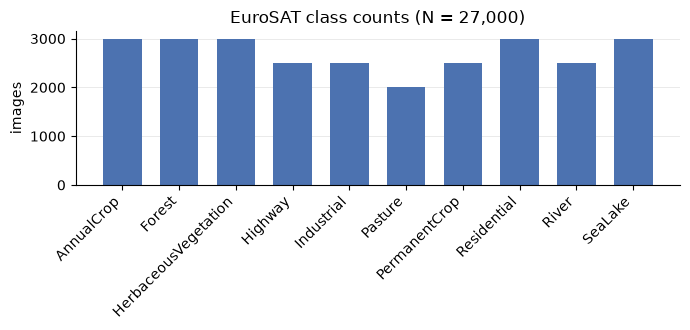

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.0, 3.4))
names = list(by_class)
ax.bar(range(len(names)), [by_class[n] for n in names], color="#4C72B0", width=0.68)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("images")
ax.set_title(f"EuroSAT class counts (N = {len(ds):,})")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()

out = REPO / "figures" / "eurosat-class-counts.png"
out.parent.mkdir(exist_ok=True)
fig.savefig(out, dpi=150, metadata={"Software": None})
print("wrote", out)

`metadata={"Software": None}` strips the matplotlib version from the PNG `tEXt` chunk.
Without it, figures drawn by different matplotlib versions differ byte-wise with
bit-identical pixels, and the repo shows a diff for a figure nothing changed about.

## 3. File ordering — why P2 depends on it

`ImageFolder.make_dataset` builds its file list with `for fname in sorted(fnames)`:
a plain lexicographic string sort. EuroSAT filenames carry an unpadded integer, so
lexicographic and numeric order disagree from the second element onwards.

`EuroSATRaw` must reproduce the lexicographic order. Sorting numerically — the more
obviously *correct* thing to do — makes index *i* a different image in each
implementation, and P2 fails on the sampled pairs while both datasets are
individually fine.

In [5]:
folder = REPO / "data" / "eurosat" / "2750" / "AnnualCrop"
names = [p.name for p in folder.iterdir() if p.suffix == ".jpg"]

lexicographic = sorted(names)
numeric = sorted(names, key=lambda s: int(s.rsplit("_", 1)[1].split(".")[0]))

print("torchvision order (sorted):      ", lexicographic[:6])
print("numeric order (what NOT to use): ", numeric[:6])
print("first index where they differ:   ",
      next(i for i, (a, b) in enumerate(zip(lexicographic, numeric)) if a != b))

torchvision order (sorted):       ['AnnualCrop_1.jpg', 'AnnualCrop_10.jpg', 'AnnualCrop_100.jpg', 'AnnualCrop_1000.jpg', 'AnnualCrop_1001.jpg', 'AnnualCrop_1002.jpg']
numeric order (what NOT to use):  ['AnnualCrop_1.jpg', 'AnnualCrop_2.jpg', 'AnnualCrop_3.jpg', 'AnnualCrop_4.jpg', 'AnnualCrop_5.jpg', 'AnnualCrop_6.jpg']
first index where they differ:    1


## 4. Normalisation constants

`Normalize(mean, std)` needs six numbers, one mean and one standard deviation per
channel. They are measured here rather than copied from a reference, and over the
**training split only** — computing them across all 27,000 images would leak test
statistics into the training pipeline (protocol §6, trap 3). The effect at this
scale is tiny; the habit is the point, and it is the same category of error as
selecting a model on the test set.

In [6]:
import sys
import dataclasses
# REPO is defined in Section 2. notebooks/ is on sys.path, the repo root is not
# 'import src...' needs the root added explicitly
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from torchvision import transforms as T

from src.config import RunConfig
from src.data import EuroSATRaw, channel_stats, make_splits

cfg = dataclasses.replace(RunConfig(), data_root=REPO/"data")
train_idx, val_idx, test_idx = make_splits(cfg)

plain = EuroSATRaw(cfg.data_root, transform=T.ToTensor())
mean, std = channel_stats(plain, train_idx)

print(f"train split: {len(train_idx):,} of {len(plain):,} images")
for name, m, s in zip(("R", "G", "B"), mean, std):
    print(f"  {name}   mean {m:.4f}   std {s:.4f}")

train split: 18,900 of 27,000 images
  R   mean 0.3440   std 0.2024
  G   mean 0.3801   std 0.1370
  B   mean 0.4076   std 0.1158


**Measured 19 September 2026**, over the 18,900 training images only.

| channel | mean | std |
|---|---|---|
| R | 0.3440 | 0.2024 |
| G | 0.3801 | 0.1370 |
| B | 0.4076 | 0.1158 |

These are computed on the train split, not all 27,000 images, so they will not
match constants published elsewhere for EuroSAT exactly. That difference is
deliberate.

The structure is physically sensible, which is a free sanity check on the whole
data path. Blue has the highest mean: Rayleigh scattering lifts the blue band over
land, so there is an atmospheric floor there that red does not have. Red has the
widest spread: chlorophyll absorbs red, so vegetation is dark in that channel while
bare soil and built-up classes are bright, which is a lot of scene-to-scene
variance. Blue is dominated by the fairly uniform atmospheric component and moves
least.

**Verified downstream.** Applying `Normalize` with these constants and averaging
2,560 training images gives per-channel mean `[0.0056, 0.0119, 0.0147]` and std
`[1.0044, 1.0092, 1.0079]` — zero and one to within 0.015. That confirms the
constants, the transform order, and that `channel_stats` and the loaders index the
same images.

In [7]:
import itertools
from src.data import make_loaders

tr, _, _ = make_loaders(cfg)
xs = torch.cat([x for x, _ in itertools.islice(tr, 20)])
print("images", xs.shape[0])
print("mean  ", [round(v, 4) for v in xs.mean(dim=(0, 2, 3)).tolist()])
print("std   ", [round(v, 4) for v in xs.std(dim=(0, 2, 3)).tolist()])

images 2560
mean   [0.0056, 0.0119, 0.0147]
std    [1.0044, 1.0092, 1.0079]
